### 1. Load Dataset

In [1]:
import pandas as pd 

dataset = pd.read_csv('../data/raw/Steel_industry_data.csv')
dataset.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### 2. Feature Engineering

In [2]:
dataset['date'] = pd.to_datetime(dataset['date'], dayfirst=True)
dataset['hour']       = dataset['date'].dt.hour
dataset['month']      = dataset['date'].dt.month
dataset['is_weekend'] = (dataset['WeekStatus'] == 'Weekend').astype(int)

### 3. Pilih Fitur untuk Clustering

In [3]:
FEATURE_COLS = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM', 'hour', 'month', 'is_weekend'
]

### 4. Train / Test Split

In [4]:
# Urut berdasarkan waktu dulu
dataset = dataset.sort_values('date').reset_index(drop=True)

# Split 80% train, 20% test — kronologis
split_idx = int(len(dataset) * 0.8)
train = dataset.iloc[:split_idx]
test  = dataset.iloc[split_idx:]

### 5. Log Transform

In [5]:
### 5. Log Transform

import numpy as np

LOG_COLS = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)'
]

# Ambil fitur mentah dulu
X_train_raw = train[FEATURE_COLS].copy()
X_test_raw  = test[FEATURE_COLS].copy()

# Log transform → simpan sebagai X_train_log (untuk visualisasi)
X_train_log = X_train_raw.copy()
X_train_log[LOG_COLS] = X_train_log[LOG_COLS].apply(np.log1p)

X_test_log = X_test_raw.copy()
X_test_log[LOG_COLS] = X_test_log[LOG_COLS].apply(np.log1p)

### 6. Robust Scaler

In [6]:
### 6. Robust Scaler

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_log)   # ← ganti dari X_train
X_test_scaled  = scaler.transform(X_test_log)         # ← ganti dari X_test

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)

### 7. Visualisasi

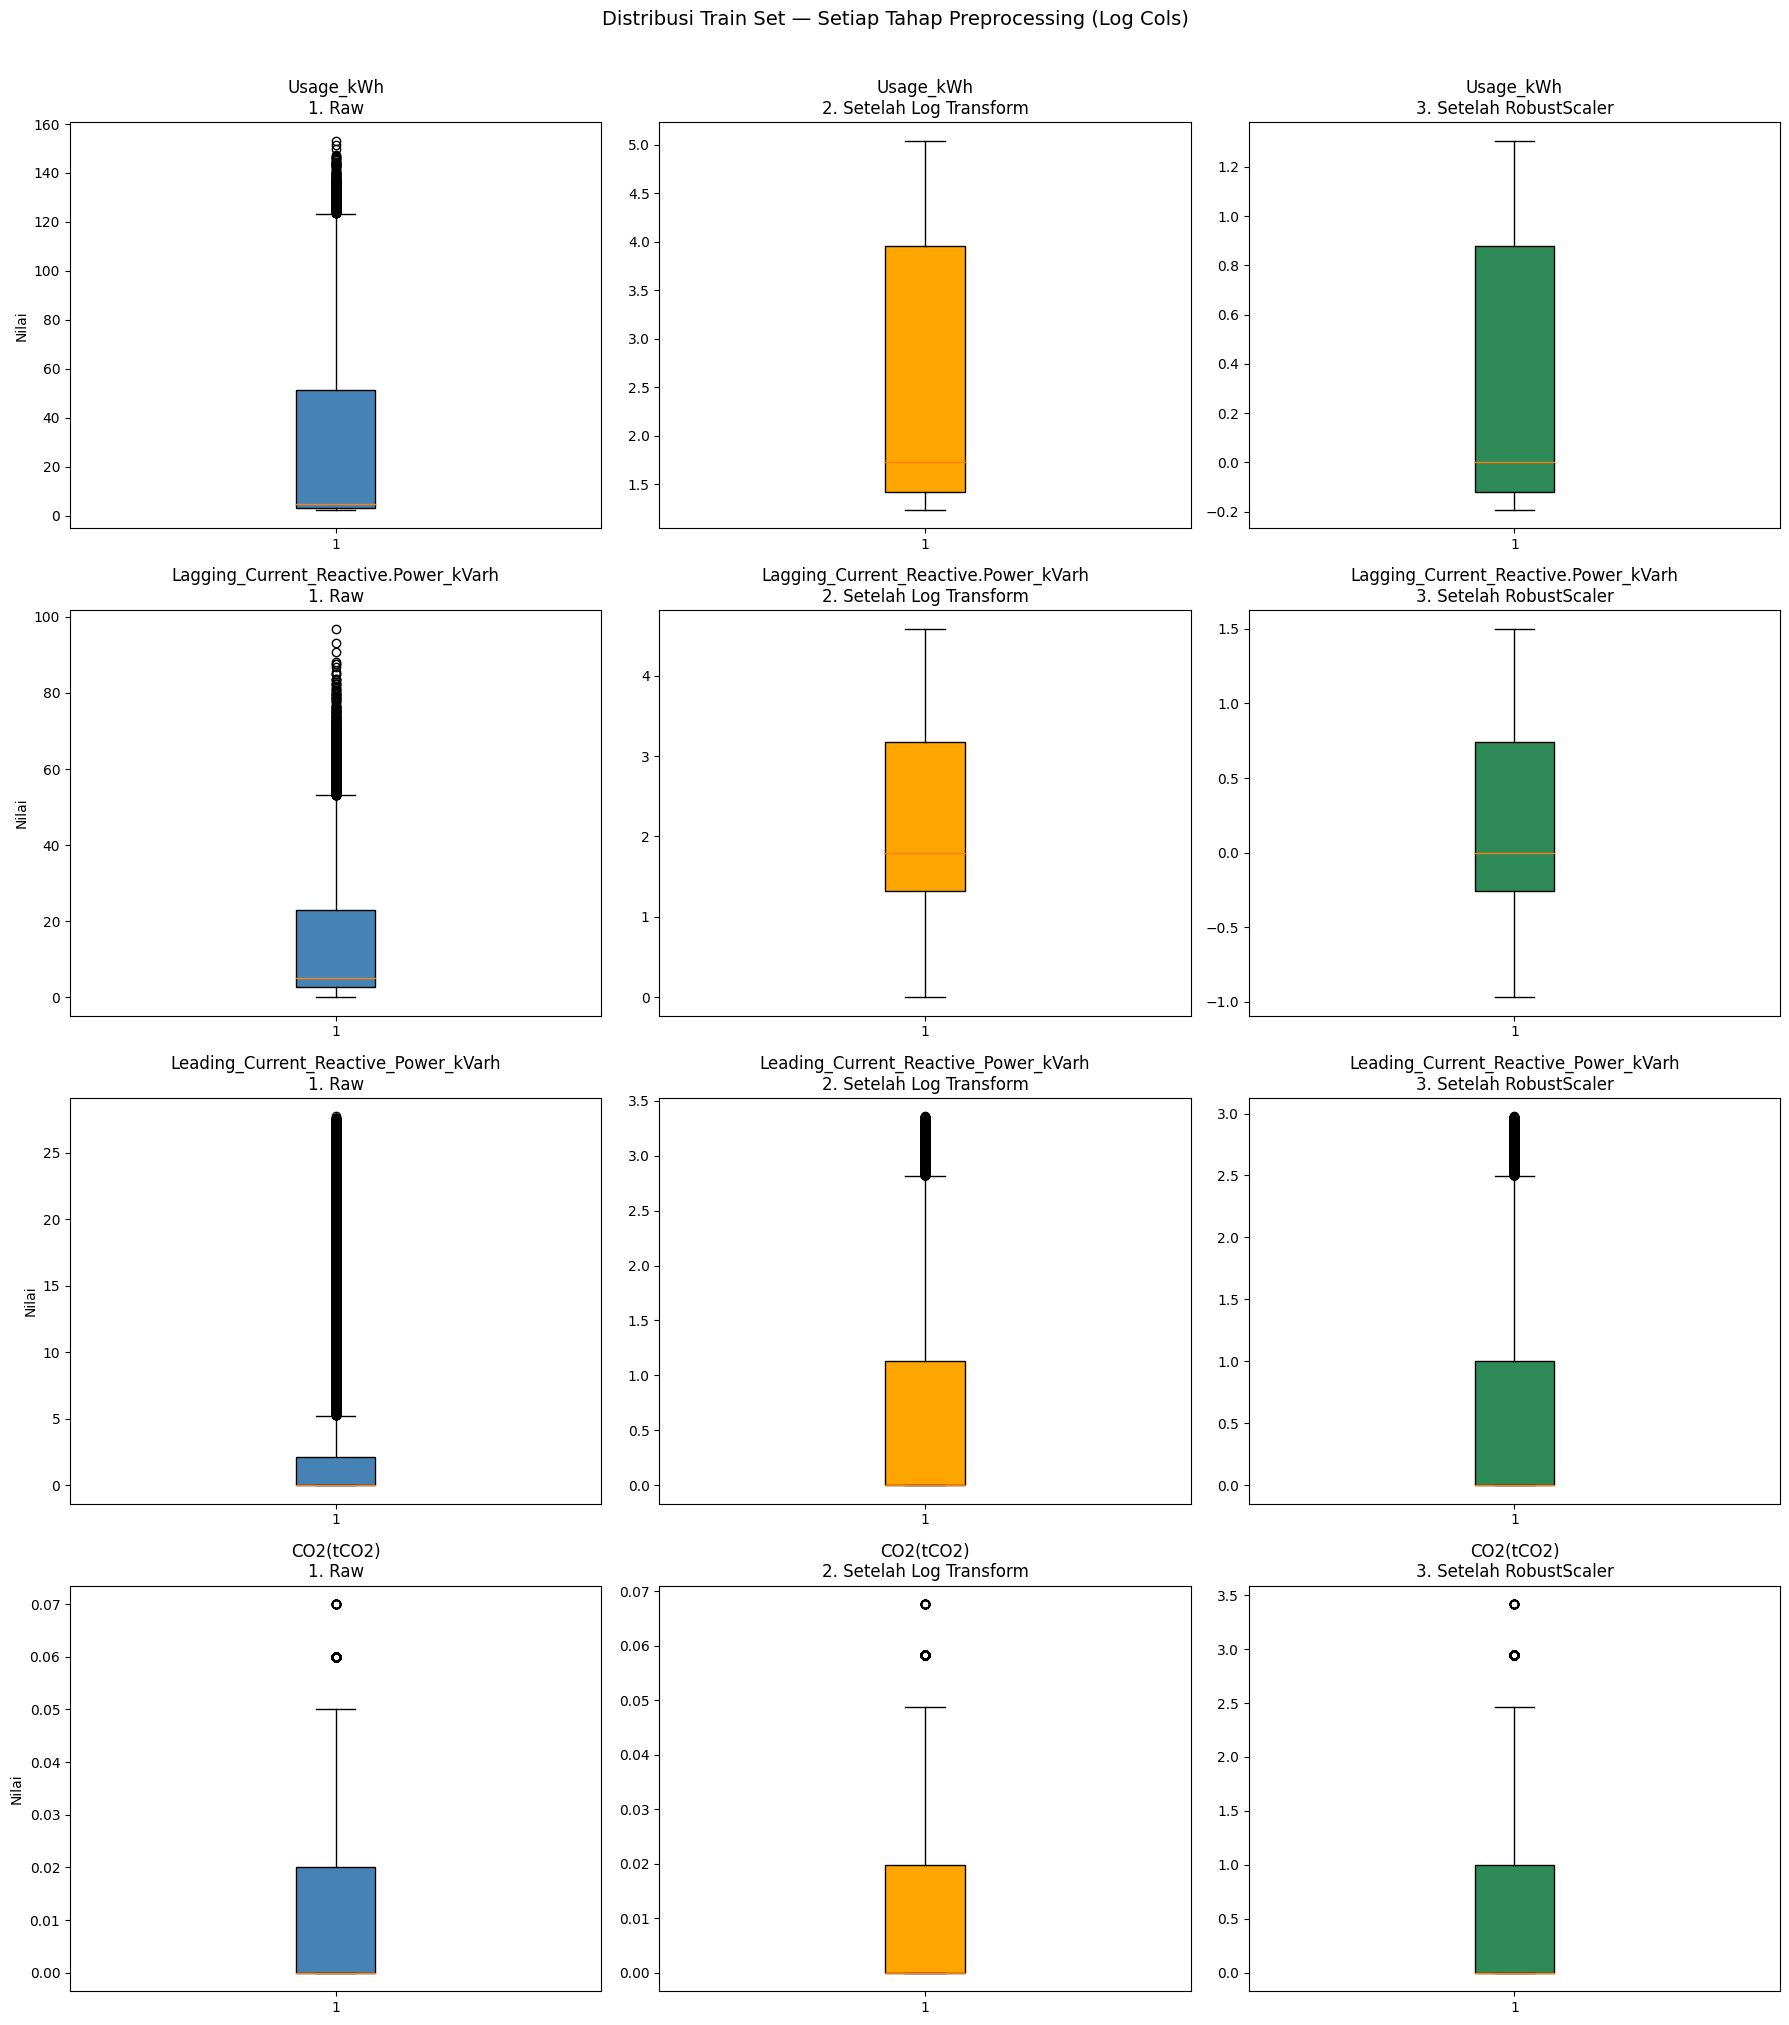

In [7]:
import matplotlib.pyplot as plt

LOG_COLS = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)'
]

fig, axes = plt.subplots(len(LOG_COLS), 3, figsize=(18, 5 * len(LOG_COLS)))

for i, col in enumerate(LOG_COLS):
    # Raw — pakai X_train_raw
    axes[i, 0].boxplot(X_train_raw[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue'))
    axes[i, 0].set_title(f'{col}\n1. Raw')
    axes[i, 0].set_ylabel('Nilai')

    # Setelah Log Transform
    axes[i, 1].boxplot(X_train_log[col], patch_artist=True,
                       boxprops=dict(facecolor='orange'))
    axes[i, 1].set_title(f'{col}\n2. Setelah Log Transform')

    # Setelah Scaling
    axes[i, 2].boxplot(X_train_scaled[col], patch_artist=True,
                       boxprops=dict(facecolor='seagreen'))
    axes[i, 2].set_title(f'{col}\n3. Setelah RobustScaler')

plt.suptitle('Distribusi Train Set — Setiap Tahap Preprocessing (Log Cols)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8. Save Result

In [8]:
import joblib

X_train_scaled.to_csv('../data/processed/train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/test_scaled.csv',   index=False)
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']